<a href="https://colab.research.google.com/github/knight-dev01/MACHING-LEARNING-DEEP-LEARNING-MASTERCLASS-WORKSHOP-2026/blob/main/Load_n_Preprocess_Data_ipnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective:
- To show you how to use CSV data with TensorFlow.

There are two main parts to this:

1. Loading the data.

2. Transform the loaded data into a suitable form for model training. This activity is popularly known as pre-processing.

Note: Comma Separated Value (CSV) represents a structured data.

In [4]:
# First thing first, we import libraries that are specific for this
# pandas is used to read-in data inform of DataFrame
import pandas as pd
# numpy is used to carryout mathematical operation on the red data
import numpy as np
# matplotlib is used to visualize data - hence, helps us to see pattern in the red data
import matplotlib.pyplot as plt
import seaborn as sns

# Why do we import seaborn since matplotlib also is for visualization?
'''
Matplotlib is a lower-level library, it doesn't calculate the KDE (Kernel Density Estimate)
line automatically therefore you will have to create the histogram and then plot a line over it.
'''

"\nMatplotlib is a lower-level library, it doesn't calculate the KDE (Kernel Density Estimate)\nline automatically therefore you will have to create the histogram and then plot a line over it.\n"

In [5]:
# This helps us control numpy decimal values display and formatting
np.set_printoptions(precision=3, suppress=True) # precision 3 means 3 decimal places

In [6]:
#  You use tf for data processing (like tf.data), saving/loading models, and low-level math
import tensorflow as tf
# Keras is the user-friendly "interface" built on top of TensorFlow.
from tensorflow.keras import layers

In [7]:
# !pip install kagglehub
import kagglehub

# user defined function
def using_kagglehub():

  # This downloads the latest version and returns the local path
  path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

  # Load the specific CSV from that path and return
  return pd.read_csv(f"{path}/Housing.csv")

In [8]:
df = using_kagglehub()
# show the first 5 row of the housing dataset
df.head()

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


About The Dataset:
The Housing Prices Dataset by Yasser H on Kaggle is a popular dataset for beginners practicing linear regression and exploratory data analysis. It focuses on predicting residential property values based on various physical and locational attributes.

Goal:
- The primary task is to build a regression model that quantitatively relates these factors to the final selling price.

Variables:

- Dependent Variable: [price]

- Independent Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

## Exploratory Data Analysis (EDA)

Why do we do EDA?
- It helps you to understand which features most impact the house price.

In [9]:
# Core EDA Steps for Housing Data

# 1. Inspection & Cleaning:

df.info() # Check if there are missing values and data types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:
# This give the statistical summary such as mean, min, max of our loaded dataset of the numerical columns.
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


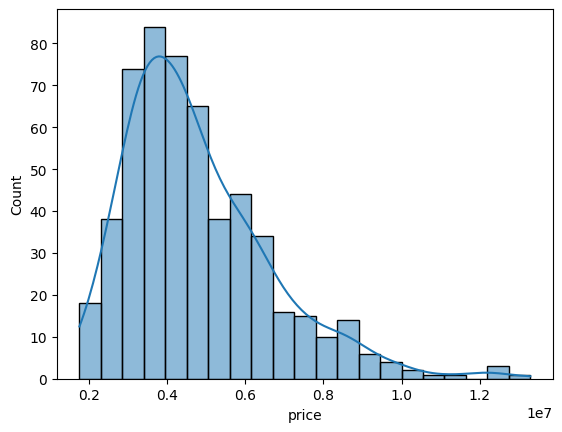

In [12]:
# 2. Univariate Analysis:
# We would plot the target variable [price] to see if it is normally distributed or skewed.
# Visualize the price distribution
sns.histplot(df['price'], kde=True)
plt.show()

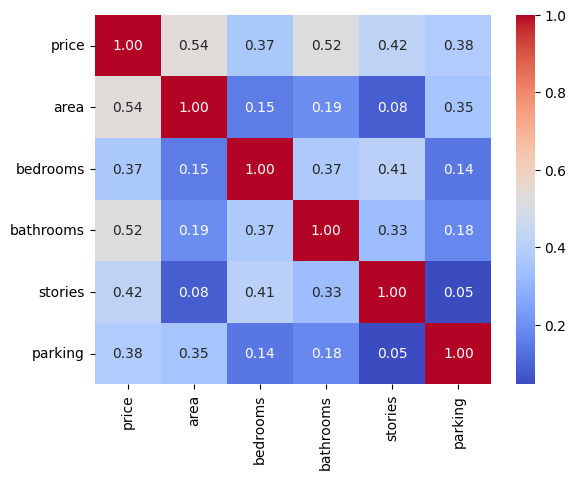

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

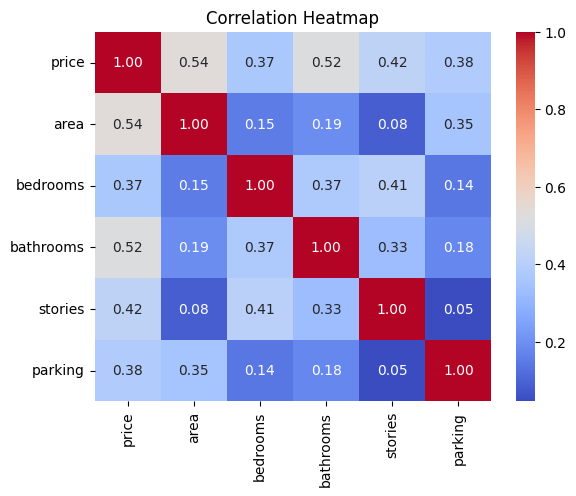

In [14]:
# Calculate correlation on numbers only
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In this context, functional density refers to how much "utility" or essential living features are packed into the house’s footprint

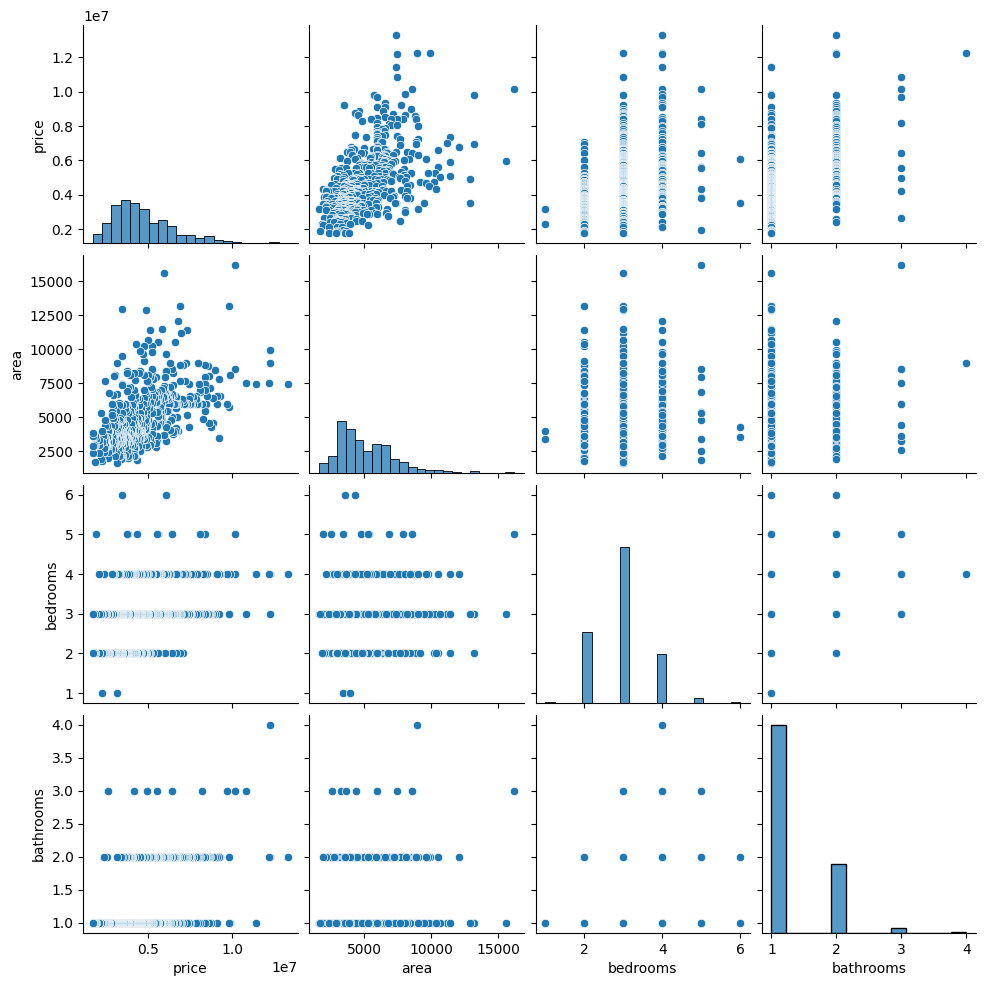

In [15]:
# 3. Compare Features with pairplot
sns.pairplot(df[['price', 'area', 'bedrooms', 'bathrooms']])
plt.show()

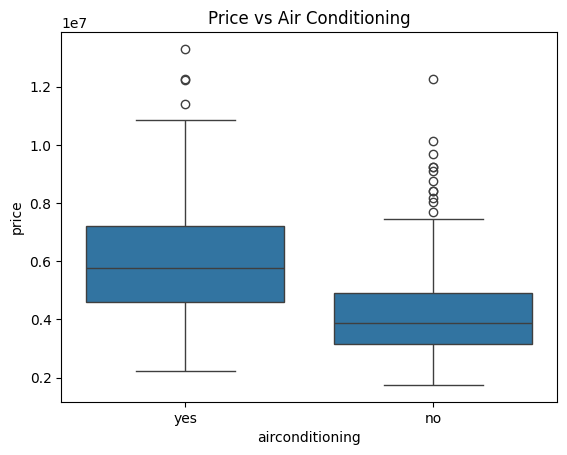

In [16]:
# 4. Visualizing Categorical Data
sns.boxplot(x='airconditioning', y='price', data=df)
plt.title("Price vs Air Conditioning")
plt.show()

The data suggests that while physical size (area) is the primary predictor, premium features like air conditioning and the number of bathrooms act as significant price multipliers. The price distribution is skewed, indicating a market dominated by mid-range housing with a small segment of high-value properties.

In [17]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
obj_cols = ['hotwaterheating',
            'airconditioning',
            'prefarea']
for c in obj_cols:
  print(df[c].value_counts())

hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64


In [19]:
# This prints the unique categories for every object column
for col in df.select_dtypes(include=['object']):
    print(f"{col}: {df[col].unique()}")

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


In [20]:
def check_category_distribution(col):
  sns.countplot(x=col, data=df)
  plt.show()

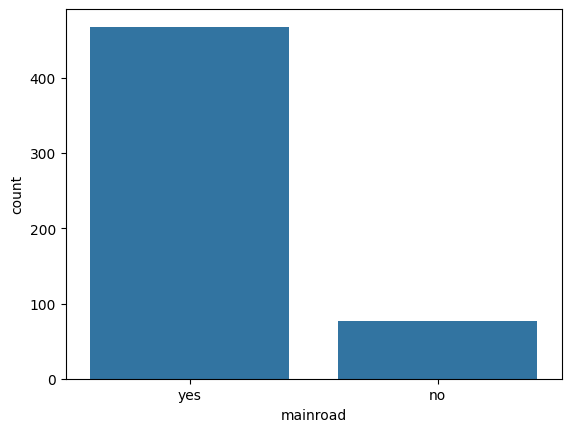

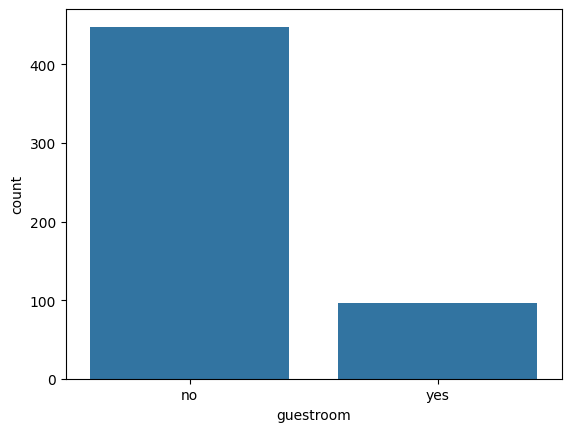

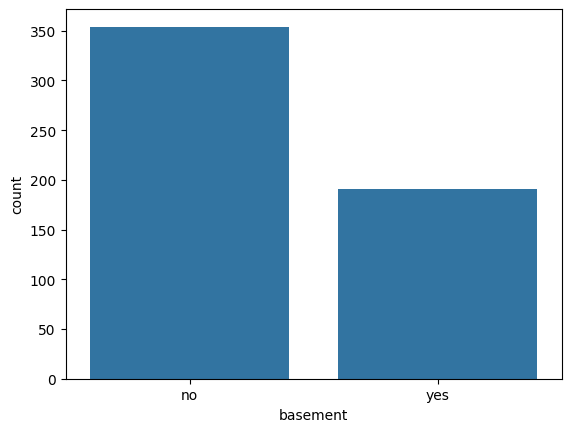

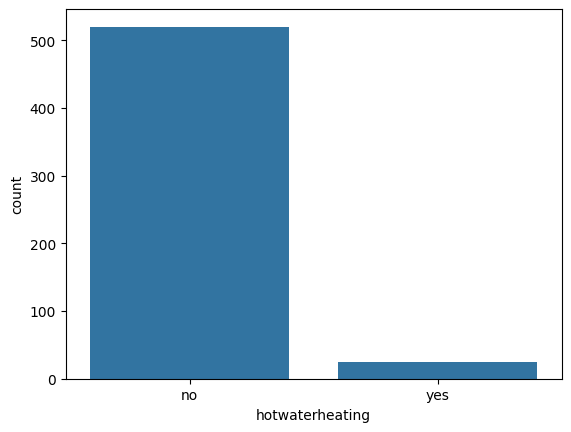

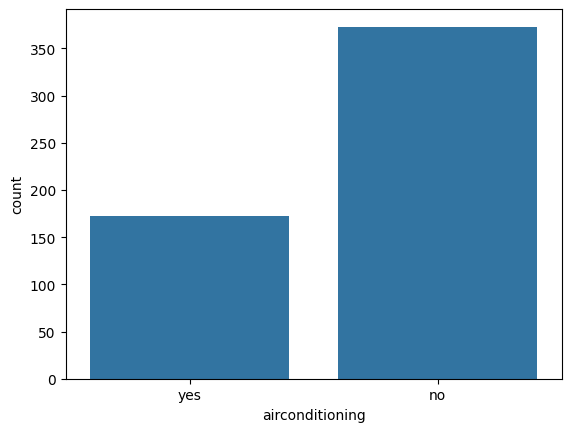

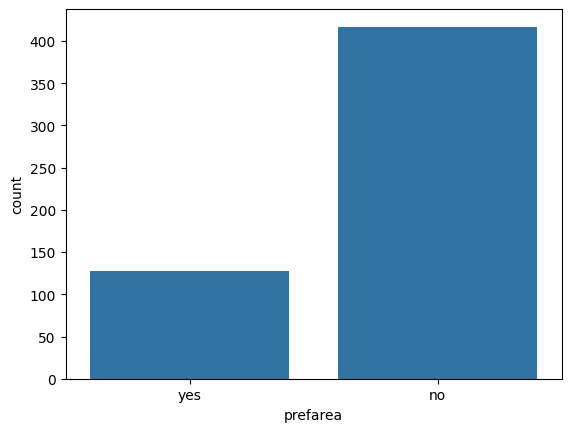

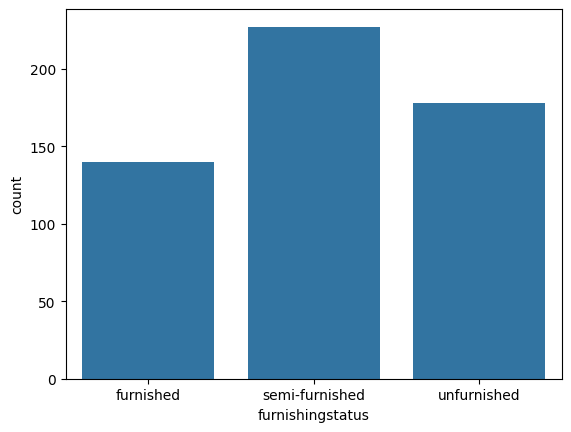

In [21]:
for col in df.select_dtypes(include=['object']):
    check_category_distribution(col)

## Why this matters for TensorFlow?

Neural networks cannot perform math on the categorical values (Yes/No). Hence, you will need to convert these to Binary i.e. to 1 and 0.

For Multiple Categories: Use One-Hot Encoding. This creates new columns for each status.

In [22]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [23]:
# List columns with two distinct values such as Yes/No
binary_cols = ['mainroad',
               'guestroom',
               'basement',
               'hotwaterheating',
               'airconditioning',
               'prefarea' ]

# Use simple mapping i.e. 'yes' to 1 and 'no' to 0
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# 3. Convert 'furnishingstatus' into separate numeric columns
# This creates columns like 'furnishingstatus_semi-furnished' and 'furnishingstatus_unfurnished'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

# Check the first few rows to see the transformation
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [24]:
# house_features = df
house_predictors = df[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']]
house_target = df.price

In [26]:
# pop the following features ['prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'] from numpy.ndarray
house_features = house_predictors.copy()
house_features.drop(columns=['prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'], inplace=True)

In [27]:
house_features = np.array(house_features)
house_target = np.array(house_target)

In [28]:
house_target.shape

(545,)

In [29]:
house_features.shape

(545, 10)

Why do we need to normalize our input for the model?

We normalize to ensure all features are of the same scale, which prevents large numbers like area from dominating the model and helps the optimizer find the best solution much faster.

In [30]:
normalize = layers.Normalization()

In [31]:
normalize.adapt(house_features)

In [55]:
house_model = tf.keras.Sequential([
    # Hidden layers. Activation funstion used is 'relu' - rectified linear unit
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'), # Extra layer to find complex patterns
    layers.Dense(16, activation='relu'), # Extra layer to find complex patterns

    # Output layer
    layers.Dense(1)
])

In [56]:

# this is like you configuring your model before training it
# Add metrics to your compile step
house_model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.004),
    metrics=['mae']
)

In [57]:
history = house_model.fit(house_features, house_target, epochs=700, verbose=1)

Epoch 1/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 26192774168576.0000 - mae: 4764684.5000
Epoch 2/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26017471135744.0000 - mae: 4748020.5000 
Epoch 3/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25214566006784.0000 - mae: 4669989.0000 
Epoch 4/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22531366977536.0000 - mae: 4399049.5000
Epoch 5/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16473646956544.0000 - mae: 3689173.0000 
Epoch 6/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7830296854528.0000 - mae: 2306427.7500  
Epoch 7/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3494230884352.0000 - mae: 1376771.8750 
Epoch 8/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3470981332992.0000 - mae: 1362479.8750
Epoch 9/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3346862964736.0000 - mae: 1350134.0000 
Epoch 10/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3358009065472.0000 - mae: 1364886.2500 
Epoch 

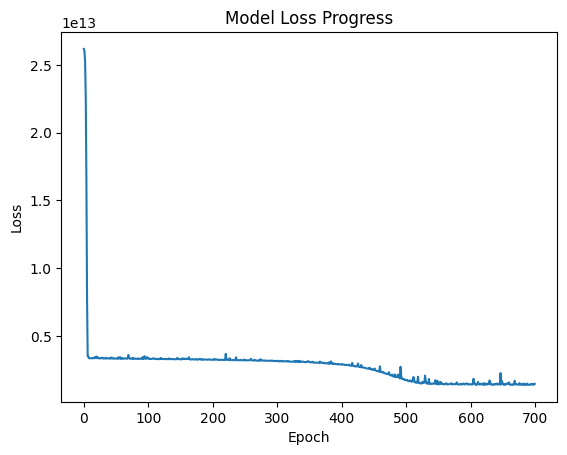

In [58]:
plt.plot(history.history['loss'])
plt.title('Model Loss Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [52]:
# 4. Check the final error
final_mae = history.history['mae'][-1]
print(f"Final Average Error: ${final_mae:,.2f}")

Final Average Error: $876,095.94


# Let's use our model to make Prediction

In [53]:
# 1. Take the first house from your features
sample_house = house_features[0].reshape(1, -1)

# 2. Let the model guess the price
prediction = house_model.predict(sample_house, verbose=0)

# 3. Compare with the actual price
actual_price = house_target[0]
error = abs(prediction[0][0] - actual_price)

print(f"Model's Predicted Price: ${prediction[0][0]:,.2f}")
print(f"Actual Market Price:    ${actual_price:,.2f}")
print(f"Difference:             ${error:,.2f}")

Model's Predicted Price: $6,729,354.00
Actual Market Price:    $13,300,000.00
Difference:             $6,570,646.00


In [ ]:
house_model.saved("house model.keras")